# 06 — Full MAPPO Training with Vectorized Environments

Training run using **parallel subprocess environments** for high throughput.
N worker processes each run their own `CrowdEnv`; the main process batches observations
for a single GPU forward pass, then distributes actions back.

5000 collect-update rollouts (each collecting 4096 agent-steps across all workers).
The total number of completed episodes depends on agent counts and episode lengths.

Curriculum progression through geometry tiers:
- **Phase 1 (Easy)**: Tier 0 open fields, 5–10 agents
- **Phase 2 (Medium)**: Tier 0–1 corridors/bottlenecks, 8–20 agents
- **Phase 3 (Hard)**: Tier 1–2 branching corridors, 15–30 agents
- **Phase 4 (Full)**: All tiers, 20–50 agents

Compact geometries (8–15m fields, 8–18m corridors) keep density high.
Rewards include inverse-distance-to-goal shaping for better intermediate signal.

In [1]:
import os
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import cm
from collections import defaultdict

from crowdrl_env.crowd_env import CrowdEnv, CrowdEnvConfig
from crowdrl_env.geometry_generator import GeometryTier, GeometryConfig
from crowdrl_env.reward import RewardConfig
from crowdrl_env.spawner import SpawnConfig
from crowdrl_env.visualiser import plot_geometry

from crowdrl_train.buffer import RolloutBuffer
from crowdrl_train.config import (
    NetworkConfig, PPOConfig, CurriculumConfig, CurriculumPhase, VecEnvConfig,
)
from crowdrl_train.curriculum import CurriculumManager, EpisodeStats
from crowdrl_train.mappo import MAPPOUpdater
from crowdrl_train.networks import ActorCritic
from crowdrl_train.normalizer import RunningNormalizer, RewardNormalizer
from crowdrl_train.vec_env import SubprocVecEnv
from crowdrl_train.rollout_collector import RolloutCollector
from crowdrl_train.train import collect_episode

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__}, device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name()}")
print(f"  CPU cores: {os.cpu_count()}")

torch 2.11.0+cu126, device: cuda
  GPU: NVIDIA RTX 5000 Ada Generation Laptop GPU
  CPU cores: 32


## 1. Training Configuration

Key choices:
- **Vectorized envs** (`N_ENVS=8`): 8 subprocess workers running CrowdEnv in parallel
- **Collect 4096 agent-steps** per rollout before each PPO update (larger batches = better GPU use)
- **Compact geometries**: fields 8–15m, corridors 8–18m — keeps density high enough for meaningful interactions even at low agent counts. Matches the scales that worked in notebook 05.
- **Inverse distance reward** (`inverse_distance_weight=0.05`): continuous proximity signal
- **Progress weight** raised to 0.5 for stronger directional shaping
- **max_steps=200**: 20s sim time — enough for compact geometries but short enough that episodes actually terminate and the curriculum can advance
- **Curriculum**: 4 phases, advance when rolling goal rate exceeds threshold

In [2]:
# --- Vectorized env config ---
N_ENVS = 64  # parallel workers
N_STEPS_PER_COLLECT = 1024  # agent-steps per PPO update
N_ROLLOUTS = 50  # number of collect-update cycles

# --- Curriculum phases ---
# Geometry stays compact throughout — crowding comes from agent count, not field size.
phases = (
    CurriculumPhase(
        name="easy",
        geometry_tiers=(GeometryTier.TIER_0,),
        n_agents_range=(5, 10),
        goal_rate_threshold=0.70,
    ),
    CurriculumPhase(
        name="medium",
        geometry_tiers=(GeometryTier.TIER_0, GeometryTier.TIER_1),
        n_agents_range=(8, 20),
        goal_rate_threshold=0.60,
    ),
    CurriculumPhase(
        name="hard",
        geometry_tiers=(GeometryTier.TIER_1, GeometryTier.TIER_2),
        n_agents_range=(15, 30),
        goal_rate_threshold=0.50,
    ),
    CurriculumPhase(
        name="full",
        geometry_tiers=(GeometryTier.TIER_0, GeometryTier.TIER_1, GeometryTier.TIER_2),
        n_agents_range=(20, 50),
        goal_rate_threshold=0.0,
    ),
)

curriculum_config = CurriculumConfig(
    phases=phases,
    metric_window=100,
    min_episodes_per_phase=500,
)

# --- Reward ---
reward_config = RewardConfig(
    goal_bonus=10.0,
    collision_penalty=-1.0,
    timeout_penalty=-5.0,
    progress_weight=0.5,
    inverse_distance_weight=0.05,
    use_smoothness=True,
)

# --- Environment base config ---
# Compact geometry: 8–15m fields, 8–18m corridors, 2–4m corridor width.
# This keeps density high and episodes short enough to learn from.
env_config = CrowdEnvConfig(
    geometry=GeometryConfig(
        min_side=8.0,
        max_side=15.0,
        corridor_width_range=(2.0, 4.0),
        corridor_length_range=(8.0, 18.0),
    ),
    reward=reward_config,
    max_steps=200,  # 20s sim time — sufficient for compact geometries
)

# --- Network ---
net_config = NetworkConfig(
    obs_dim=env_config.obs.obs_dim,
    action_dim=env_config.action.action_dim,
    actor_hidden_sizes=(128, 128),
    critic_hidden_sizes=(128, 128),
)

ppo_config = PPOConfig(
    lr_actor=5e-4,
    lr_critic=5e-4,
    n_epochs=10,
    clip_epsilon=0.2,
    gamma=0.99,
    gae_lambda=0.95,
    target_kl=0.02,
    lr_schedule="linear",
)

SEED = 42
LOG_INTERVAL = 5  # print every 5 rollouts (more frequent feedback)

print(f"Vectorized training: {N_ENVS} workers, {N_STEPS_PER_COLLECT} steps/collect")
print(f"Target: {N_ROLLOUTS} rollouts")
print(f"Curriculum: {' -> '.join(p.name for p in phases)}")
print(f"max_steps={env_config.max_steps} ({env_config.max_steps * env_config.dt:.0f}s sim time)")
print(f"Geometry: fields {env_config.geometry.min_side}-{env_config.geometry.max_side}m, "
      f"corridors {env_config.geometry.corridor_length_range[0]}-"
      f"{env_config.geometry.corridor_length_range[1]}m")
print(f"Reward: progress={reward_config.progress_weight}, "
      f"inv_dist={reward_config.inverse_distance_weight}, "
      f"goal={reward_config.goal_bonus}")

Vectorized training: 64 workers, 1024 steps/collect
Target: 50 rollouts
Curriculum: easy -> medium -> hard -> full
max_steps=200 (20s sim time)
Geometry: fields 8.0-15.0m, corridors 8.0-18.0m
Reward: progress=0.5, inv_dist=0.05, goal=10.0


## 2. Initialise Training Components

In [3]:
torch.manual_seed(SEED)
np.random.seed(SEED)

actor_critic = ActorCritic(net_config).to(device)
updater = MAPPOUpdater(actor_critic, ppo_config, device)
curriculum = CurriculumManager(curriculum_config)

obs_normalizer = RunningNormalizer(shape=(net_config.obs_dim,))
reward_normalizer = RewardNormalizer(gamma=ppo_config.gamma)

n_params = sum(p.numel() for p in actor_critic.parameters())
print(f"Actor-Critic: {n_params:,} parameters")
print(f"Starting phase: {curriculum.current_phase.name}")

Actor-Critic: 54,153 parameters
Starting phase: easy


## 3. Training Loop — Vectorized

N workers run `CrowdEnv` in parallel subprocesses. Each rollout:
1. Collect ~4096 agent-steps across all workers (central GPU inference)
2. Compute GAE with per-episode bootstrap values
3. Single PPO update on the full batch
4. Report completed episodes to curriculum manager

In [4]:
# Launch vectorized environment
cur_env_config = curriculum.make_env_config(env_config)
seeds = [SEED + i for i in range(N_ENVS)]
vec_env = SubprocVecEnv(cur_env_config, seeds)

collector = RolloutCollector(
    vec_env, actor_critic,
    obs_normalizer, reward_normalizer, device,
    obs_dim=net_config.obs_dim, action_dim=net_config.action_dim,
)

# Training history
history = defaultdict(list)
phase_transitions = []
total_agent_steps = 0
total_episodes = 0
start_time = time.time()

print(f"{'Roll':>5} | {'Episodes':>8} | {'Steps':>12} | {'GoalRate':>8} | "
      f"{'Reward':>8} | {'Phase':>8} | {'SPS':>8}", flush=True)
print("-" * 80, flush=True)

try:
    for rollout in range(1, N_ROLLOUTS + 1):
        # --- Collect rollouts from all envs (per-env buffers) ---
        episode_stats_list = collector.collect(N_STEPS_PER_COLLECT)

        # --- GAE per env buffer + merge into single FlatBatch ---
        flat_batch = collector.compute_gae_and_flatten(
            ppo_config.gamma, ppo_config.gae_lambda,
        )

        # --- PPO update ---
        if flat_batch.batch_size > 0:
            update_metrics = updater.update(flat_batch)
        else:
            update_metrics = {}

        batch_steps = collector.total_active_agent_steps
        total_agent_steps += batch_steps
        total_episodes += len(episode_stats_list)

        # --- LR decay ---
        progress = rollout / N_ROLLOUTS
        updater.update_learning_rate(progress)

        # --- Record history ---
        for ep in episode_stats_list:
            history["goal_rate"].append(ep["goal_rate"])
            history["mean_reward"].append(ep["mean_reward"])
            history["episode_length"].append(ep["episode_length"])
            history["n_agents"].append(ep["n_agents"])
            history["phase_idx"].append(curriculum.current_phase_idx)

        if update_metrics:
            history["policy_loss"].append(update_metrics.get("policy_loss", 0))
            history["value_loss"].append(update_metrics.get("value_loss", 0))
            history["entropy"].append(update_metrics.get("entropy", 0))
            history["approx_kl"].append(update_metrics.get("approx_kl", 0))

        # --- Curriculum ---
        phase_advanced = False
        for ep in episode_stats_list:
            cs = EpisodeStats(
                goal_rate=ep["goal_rate"],
                n_agents=ep["n_agents"],
                episode_length=ep["episode_length"],
                mean_reward=ep["mean_reward"],
            )
            if curriculum.report_episode(cs):
                phase_advanced = True

        if phase_advanced:
            phase_transitions.append((total_episodes, curriculum.current_phase.name))
            cur_env_config = curriculum.make_env_config(env_config)
            new_seeds = [SEED + rollout * N_ENVS + i for i in range(N_ENVS)]
            vec_env.update_all_configs(cur_env_config, new_seeds[0])
            print(f"\n>>> Phase advanced to: {curriculum.current_phase.name} "
                  f"(episode {total_episodes})\n", flush=True)

        # --- Logging ---
        if rollout % LOG_INTERVAL == 0 and episode_stats_list:
            elapsed = time.time() - start_time
            sps = total_agent_steps / max(elapsed, 1)
            window = min(100, len(history["goal_rate"]))
            avg_gr = np.mean(history["goal_rate"][-window:])
            avg_rw = np.mean(history["mean_reward"][-window:])
            print(
                f"{rollout:>5} | {total_episodes:>8} | {total_agent_steps:>12,} | "
                f"{avg_gr:>8.3f} | {avg_rw:>8.2f} | "
                f"{curriculum.current_phase.name:>8} | {sps:>8.0f}",
                flush=True,
            )

finally:
    vec_env.close()

elapsed = time.time() - start_time
print(f"\nDone: {total_episodes} episodes, {total_agent_steps:,} agent-steps in {elapsed:.1f}s")
print(f"Throughput: {total_agent_steps / elapsed:.0f} agent-steps/sec")
print(f"Phase transitions: {phase_transitions}")

 Roll | Episodes |        Steps | GoalRate |   Reward |    Phase |      SPS
--------------------------------------------------------------------------------

Done: 0 episodes, 71,758 agent-steps in 40.6s
Throughput: 1769 agent-steps/sec
Phase transitions: []


## 4. Training Curves

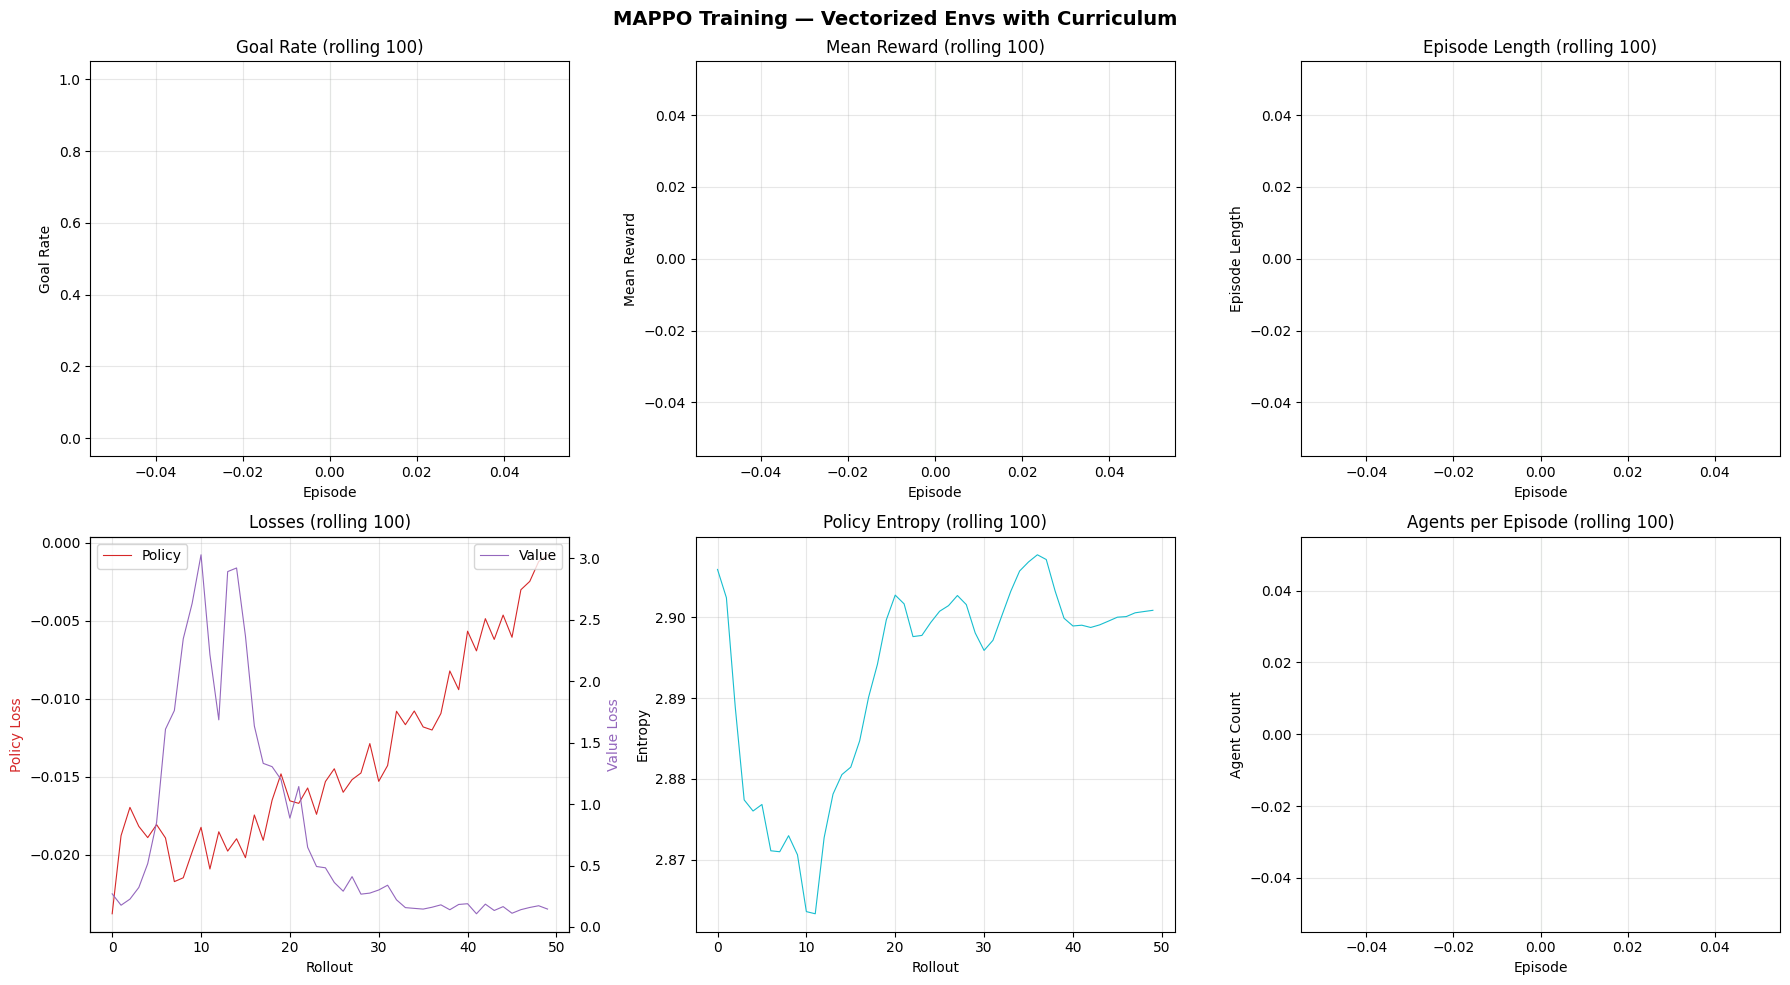

In [5]:
def smooth(values, window=100):
    """Rolling mean with edge handling."""
    if len(values) < window:
        return np.array(values)
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Phase background shading
phase_colors = ["#e8f5e9", "#fff3e0", "#fce4ec", "#e3f2fd"]
phase_names_unique = ["easy", "medium", "hard", "full"]

def add_phase_bg(ax):
    prev_ep = 0
    for ep_idx, name in phase_transitions:
        pidx = phase_names_unique.index(name) - 1
        if 0 <= pidx < len(phase_colors):
            ax.axvspan(prev_ep, ep_idx, alpha=0.3, color=phase_colors[pidx])
        prev_ep = ep_idx
    if phase_transitions:
        last_pidx = phase_names_unique.index(phase_transitions[-1][1])
        ax.axvspan(prev_ep, len(history["goal_rate"]), alpha=0.3,
                   color=phase_colors[min(last_pidx, 3)])
    else:
        ax.axvspan(0, len(history["goal_rate"]), alpha=0.3, color=phase_colors[0])

# Goal rate
ax = axes[0, 0]
add_phase_bg(ax)
ax.plot(smooth(history["goal_rate"]), color="tab:green", linewidth=0.8)
ax.set_ylabel("Goal Rate")
ax.set_xlabel("Episode")
ax.set_title("Goal Rate (rolling 100)")
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)

# Mean reward
ax = axes[0, 1]
add_phase_bg(ax)
ax.plot(smooth(history["mean_reward"]), color="tab:blue", linewidth=0.8)
ax.set_ylabel("Mean Reward")
ax.set_xlabel("Episode")
ax.set_title("Mean Reward (rolling 100)")
ax.grid(True, alpha=0.3)

# Episode length
ax = axes[0, 2]
add_phase_bg(ax)
ax.plot(smooth(history["episode_length"]), color="tab:orange", linewidth=0.8)
ax.set_ylabel("Episode Length")
ax.set_xlabel("Episode")
ax.set_title("Episode Length (rolling 100)")
ax.grid(True, alpha=0.3)

# Losses
ax = axes[1, 0]
if history["policy_loss"]:
    ax.plot(smooth(history["policy_loss"]), color="tab:red", linewidth=0.8, label="Policy")
    ax2 = ax.twinx()
    ax2.plot(smooth(history["value_loss"]), color="tab:purple", linewidth=0.8, label="Value")
    ax2.set_ylabel("Value Loss", color="tab:purple")
    ax.legend(loc="upper left")
    ax2.legend(loc="upper right")
ax.set_ylabel("Policy Loss", color="tab:red")
ax.set_xlabel("Rollout")
ax.set_title("Losses (rolling 100)")
ax.grid(True, alpha=0.3)

# Entropy
ax = axes[1, 1]
if history["entropy"]:
    ax.plot(smooth(history["entropy"]), color="tab:cyan", linewidth=0.8)
ax.set_ylabel("Entropy")
ax.set_xlabel("Rollout")
ax.set_title("Policy Entropy (rolling 100)")
ax.grid(True, alpha=0.3)

# Agent count + phases
ax = axes[1, 2]
add_phase_bg(ax)
ax.plot(smooth(history["n_agents"]), color="tab:brown", linewidth=0.8)
ax.set_ylabel("Agent Count")
ax.set_xlabel("Episode")
ax.set_title("Agents per Episode (rolling 100)")
ax.grid(True, alpha=0.3)
for ep_idx, name in phase_transitions:
    ax.axvline(ep_idx, color="red", linestyle="--", alpha=0.7)
    ax.text(ep_idx, ax.get_ylim()[1] * 0.95, f" {name}", fontsize=8, color="red")

fig.suptitle("MAPPO Training — Vectorized Envs with Curriculum", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Per-Phase Performance Summary

In [6]:
phase_idx_arr = np.array(history["phase_idx"])
goal_rate_arr = np.array(history["goal_rate"])
reward_arr = np.array(history["mean_reward"])
length_arr = np.array(history["episode_length"])
agents_arr = np.array(history["n_agents"])

print(f"{'Phase':<10} {'Episodes':>8} {'GoalRate':>10} {'Reward':>10} {'EpLen':>8} {'Agents':>8}")
print("-" * 60)
for pidx, phase in enumerate(phases):
    mask = phase_idx_arr == pidx
    if not mask.any():
        continue
    n_eps = mask.sum()
    print(
        f"{phase.name:<10} {n_eps:>8} {goal_rate_arr[mask].mean():>10.3f} "
        f"{reward_arr[mask].mean():>10.2f} {length_arr[mask].mean():>8.1f} "
        f"{agents_arr[mask].mean():>8.1f}"
    )

print(f"\nFinal 500 episodes:")
print(f"  Goal rate: {np.mean(history['goal_rate'][-500:]):.3f}")
print(f"  Mean reward: {np.mean(history['mean_reward'][-500:]):.2f}")

Phase      Episodes   GoalRate     Reward    EpLen   Agents
------------------------------------------------------------

Final 500 episodes:
  Goal rate: nan
  Mean reward: nan


C:\Users\Fabian\dev\CrowdRL\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\Fabian\dev\CrowdRL\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


## 6. Evaluation — Trajectory Visualisation

Run the trained policy on example geometries from each tier and plot agent trajectories.

C:\Users\Fabian\AppData\Local\Temp\ipykernel_38408\3318732883.py:76: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", n_agents)
C:\Users\Fabian\AppData\Local\Temp\ipykernel_38408\3318732883.py:76: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", n_agents)
C:\Users\Fabian\AppData\Local\Temp\ipykernel_38408\3318732883.py:76: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", n_agents)
C:\User

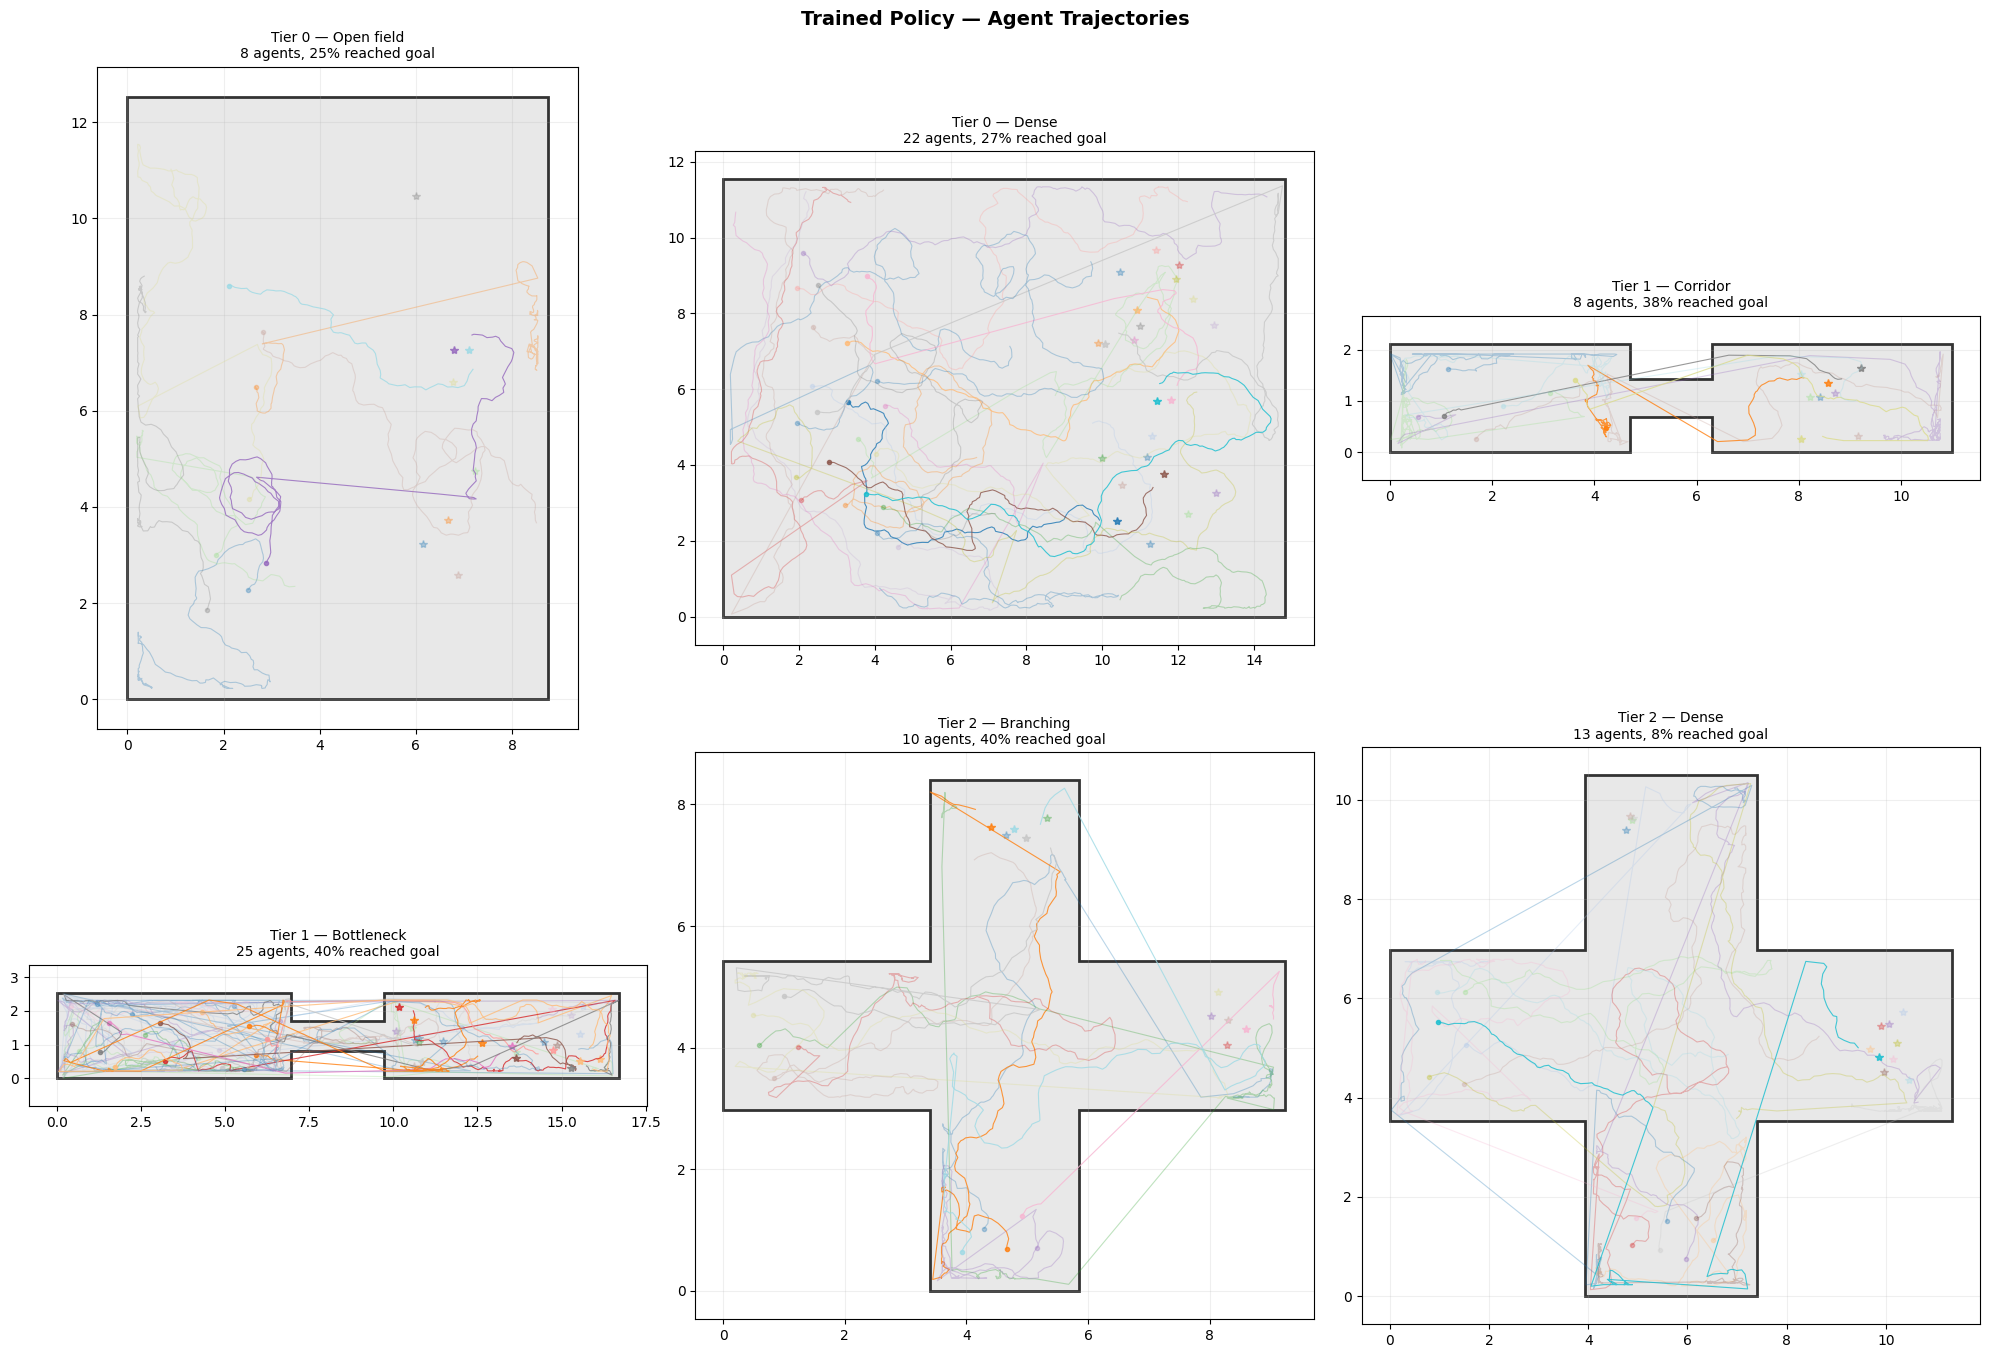

In [7]:
def run_episode_with_trajectories(env, actor_critic, obs_normalizer, device, max_steps=200):
    """Run one episode collecting full agent trajectories."""
    obs, info = env.reset()
    n_agents = info["n_agents"]
    trajectories = [[] for _ in range(n_agents)]
    goal_positions = env._world.goal_positions.copy()
    polygon = env._world.walkable_polygon
    reached_goal = np.zeros(n_agents, dtype=bool)

    for i in range(n_agents):
        trajectories[i].append(env._world.positions[i].copy())

    for step in range(max_steps):
        if obs_normalizer is not None:
            obs_norm = obs_normalizer.normalize(obs)
        else:
            obs_norm = obs

        with torch.no_grad():
            obs_t = torch.as_tensor(obs_norm, dtype=torch.float32, device=device)
            actions, _, _, _, _ = actor_critic.get_action_and_value(obs_t)

        obs, rewards, terminated, truncated, step_info = env.step(actions.cpu().numpy())

        for i in range(n_agents):
            trajectories[i].append(env._world.positions[i].copy())

        reached_goal |= terminated

        if step_info.get("episode_over", False):
            break

    return trajectories, goal_positions, polygon, reached_goal, info


# Compact geometries matching training — density matters more than scale
eval_geometry = GeometryConfig(
    min_side=8.0, max_side=15.0,
    corridor_width_range=(2.0, 4.0),
    corridor_length_range=(8.0, 18.0),
)

eval_tiers = [
    ("Tier 0 — Open field", GeometryTier.TIER_0, (5, 10)),
    ("Tier 0 — Dense", GeometryTier.TIER_0, (15, 25)),
    ("Tier 1 — Corridor", GeometryTier.TIER_1, (8, 15)),
    ("Tier 1 — Bottleneck", GeometryTier.TIER_1, (15, 25)),
    ("Tier 2 — Branching", GeometryTier.TIER_2, (10, 20)),
    ("Tier 2 — Dense", GeometryTier.TIER_2, (20, 35)),
]

fig, axes = plt.subplots(2, 3, figsize=(20, 14))
axes_flat = axes.flatten()

actor_critic.eval()

for idx, (title, tier, agent_range) in enumerate(eval_tiers):
    ax = axes_flat[idx]

    eval_env_config = CrowdEnvConfig(
        geometry=eval_geometry,
        geometry_tiers=[tier],
        spawn=SpawnConfig(n_agents_range=agent_range),
        reward=reward_config,
        max_steps=200,
    )
    eval_env = CrowdEnv(config=eval_env_config, seed=SEED + idx + 100)

    trajs, goals, polygon, reached, info = run_episode_with_trajectories(
        eval_env, actor_critic, obs_normalizer, device
    )

    plot_geometry(polygon, ax=ax)

    n_agents = len(trajs)
    cmap = cm.get_cmap("tab20", n_agents)
    for i in range(n_agents):
        traj = np.array(trajs[i])
        color = cmap(i % 20)
        alpha = 0.8 if reached[i] else 0.3
        ax.plot(traj[:, 0], traj[:, 1], color=color, linewidth=0.8, alpha=alpha)
        ax.plot(traj[0, 0], traj[0, 1], "o", color=color, markersize=3, alpha=alpha)
        ax.plot(goals[i, 0], goals[i, 1], "*", color=color, markersize=6, alpha=alpha)

    goal_rate = reached.sum() / n_agents if n_agents > 0 else 0
    ax.set_title(f"{title}\n{n_agents} agents, {goal_rate:.0%} reached goal", fontsize=10)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.2)

actor_critic.train()

fig.suptitle("Trained Policy — Agent Trajectories", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Quantitative Evaluation

Run 50 evaluation episodes per tier to get statistically meaningful performance numbers.

In [8]:
N_EVAL = 50
eval_results = {}

actor_critic.eval()

for tier in [GeometryTier.TIER_0, GeometryTier.TIER_1, GeometryTier.TIER_2]:
    tier_stats = {"goal_rate": [], "mean_reward": [], "episode_length": [], "n_agents": []}

    eval_env_config = CrowdEnvConfig(
        geometry=eval_geometry,
        geometry_tiers=[tier],
        spawn=SpawnConfig(n_agents_range=(8, 25)),
        reward=reward_config,
        max_steps=200,
    )
    eval_env = CrowdEnv(config=eval_env_config, seed=SEED + 1000)
    eval_buffer = RolloutBuffer(net_config.obs_dim, net_config.action_dim, device)

    for i in range(N_EVAL):
        ep_stats = collect_episode(
            eval_env, actor_critic, eval_buffer, obs_normalizer, None, device
        )
        eval_buffer.clear()
        tier_stats["goal_rate"].append(ep_stats["goal_rate"])
        tier_stats["mean_reward"].append(ep_stats["mean_reward"])
        tier_stats["episode_length"].append(ep_stats["episode_length"])
        tier_stats["n_agents"].append(ep_stats["n_agents"])

    eval_results[tier.name] = tier_stats

actor_critic.train()

print(f"{'Tier':<10} {'GoalRate':>10} {'Reward':>10} {'EpLen':>8} {'Agents':>8}")
print("-" * 50)
for tier_name, stats in eval_results.items():
    print(
        f"{tier_name:<10} "
        f"{np.mean(stats['goal_rate']):>8.3f}\u00b1{np.std(stats['goal_rate']):.3f} "
        f"{np.mean(stats['mean_reward']):>8.2f}\u00b1{np.std(stats['mean_reward']):.2f} "
        f"{np.mean(stats['episode_length']):>6.0f}\u00b1{np.std(stats['episode_length']):.0f} "
        f"{np.mean(stats['n_agents']):>6.1f}"
    )

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
tier_names = list(eval_results.keys())
x = np.arange(len(tier_names))

for ax, metric, ylabel in zip(
    axes,
    ["goal_rate", "mean_reward", "episode_length"],
    ["Goal Rate", "Mean Reward", "Episode Length"],
):
    means = [np.mean(eval_results[t][metric]) for t in tier_names]
    stds = [np.std(eval_results[t][metric]) for t in tier_names]
    ax.bar(x, means, yerr=stds, capsize=5, color=["#4CAF50", "#FF9800", "#F44336"])
    ax.set_xticks(x)
    ax.set_xticklabels(tier_names)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.grid(True, alpha=0.3, axis="y")

fig.suptitle(f"Evaluation Performance ({N_EVAL} episodes per tier)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

## 8. Export

Save the trained policy as ONNX for deployment in JuPedSim.

In [ ]:
from crowdrl_train.export import export_onnx
from pathlib import Path

onnx_path = Path("outputs/06_full_training/policy.onnx")
export_onnx(actor_critic.actor, obs_normalizer, onnx_path)
print(f"ONNX policy exported to: {onnx_path}")
print(f"File size: {onnx_path.stat().st_size / 1024:.1f} KB")

from crowdrl_train.train import save_checkpoint

ckpt_path = Path("outputs/06_full_training/checkpoint_final.pt")
save_checkpoint(
    ckpt_path, actor_critic, updater,
    obs_normalizer, reward_normalizer, curriculum,
    total_agent_steps, total_episodes,
)
print(f"Checkpoint saved to: {ckpt_path}")